# SEA-Rater — Pipeline 

Selects documents from FineWeb2 for human annotation.
Uses the **Gemini API** to pre-score five quality dimensions.

**Priorities (from project spec):**
1. **Primary:** broad score-range coverage across all 5 quality dimensions
   (Educational Value, Reasoning, Professionalism, Cleanliness, Cultural Nuances).
2. **Secondary:** diversity in document length and language score.

**Pipeline:**
1. Stream a candidate pool from two FineWeb2 subsets: `vie_Latn` (filtered clean) and `vie_Latn_removed` (heuristic-excluded, post-dedup).
2. Assign length and language-score buckets (cheap metadata axes — no Gemini calls).
3. Score batches of 300 with Gemini; print gap table after each batch.
4. Stop when every reachable (dimension, score-value) bin reaches `FLOOR`,
   or the budget / pool is exhausted.
5. Select exactly 940 docs: score-bin diversity first, length and language score diversity as tiebreaker.

## 1. Install dependencies


In [57]:
!pip -q install -U datasets google-genai pandas numpy pyarrow tqdm tenacity matplotlib datatrove[io]

## 2. Configuration

Set your Gemini API key and run parameters here. Defaults match the project spec.


In [58]:
import os, json, time, re, random
from pathlib import Path
import numpy as np 

# --- Gemini API key ---
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None
GEMINI_API_KEY = (
    GEMINI_API_KEY
    or os.environ.get("GEMINI_API_KEY")
    or "PASTE_YOUR_KEY_HERE"
)

# --- Model (confirm exact id in the next cell) ---
MODEL_NAME = "gemini-3.1-flash-lite"

# --- Language ---
TARGET_LANGUAGE = "Lao"   # human-readable name — used in Cultural Nuances rubric
HF_CONFIG       = "lao_Laoo"     # FineWeb2 config name for the language
# Other SEA languages: ind_Latn (Indonesian), tha_Thai (Thai), zsm_Latn (Malay),
#   fil_Latn (Filipino), mya_Mymr (Burmese), khm_Khmr (Khmer), lao_Laoo (Lao)

# --- Dataset ---
HF_DATASET        = "HuggingFaceFW/fineweb-2"
HF_CONFIG_REMOVED = f"{HF_CONFIG}_removed"   # heuristic-filtered-out set
HF_SPLIT          = "train"

# --- Pool & targets ---
CLEAN_RATIO       = 0.70   # fraction of pool and final selection from clean source

POOL_SIZE_TOTAL   = 50000    # total raw docs to stream        
POOL_SIZE         = round(POOL_SIZE_TOTAL * CLEAN_RATIO)   # clean docs 
POOL_SIZE_REMOVED = POOL_SIZE_TOTAL - POOL_SIZE            # removed docs 

BATCH_SIZE        = 300     # docs scored per round
TARGET_TOTAL      = 940     # total final docs selected       
TARGET_CLEAN      = round(TARGET_TOTAL * CLEAN_RATIO)      
TARGET_REMOVED    = TARGET_TOTAL - TARGET_CLEAN            

FLOOR             = 25      # desired minimum per (dimension, score-value) bin
GIVE_UP_AFTER     = 2      # consecutive batches without total-gap improvement -> give up
MAX_GEMINI_CALLS  = 5000   # hard cap on Gemini calls

# --- Document length window (fixed bounds) ---
MIN_CHARS     = 500   # hard lower bound — enforced during streaming
MAX_DOC_CHARS = 4000   # hard upper bound — docs longer than this are excluded

# --- Length bucket percentiles ---
LEN_Q = (0.20, 0.80)   # p20/p80 → short / medium / long boundaries

# --- Language-score bucket boundaries (p20/p80 per source → low / medium / high) ---
LANG_Q      = (0.20, 0.80)

# --- Selection diversity targets (must each sum to 1.0) ---
LEN_TARGET_FRAC  = {"short": 1/3, "medium": 1/3, "long": 1/3}
LANG_TARGET_FRAC = {"low": 0.1, "medium": 0.2, "high": 0.7}

print("Pool ratio: %.0f%% clean / %.0f%% removed  (CLEAN_RATIO=%.2f)"
      % (CLEAN_RATIO * 100, (1 - CLEAN_RATIO) * 100, CLEAN_RATIO))
print("Pool:   %d total → %d clean + %d removed" % (POOL_SIZE_TOTAL, POOL_SIZE, POOL_SIZE_REMOVED))
print("Target: %d total → %d clean + %d removed" % (TARGET_TOTAL, TARGET_CLEAN, TARGET_REMOVED))
print("Length window: [%d, %d] | LEN_Q=%s (computed on filtered pool)" % (MIN_CHARS, MAX_DOC_CHARS, LEN_Q))
print("Selection fracs — len: %s | lang: %s" % (
    {k: "%.0f%%" % (v*100) for k, v in LEN_TARGET_FRAC.items()},
    {k: "%.0f%%" % (v*100) for k, v in LANG_TARGET_FRAC.items()},
))

# --- Concurrency / robustness ---
MAX_WORKERS = 8
TEMPERATURE = 0.0

# --- Output paths ---
WORK = Path.cwd()/"data_revised"/HF_CONFIG
WORK.mkdir(parents=True, exist_ok=True)

POOL_PARQUET        = WORK / "pool.parquet"
ADULT_FILTERED_CSV  = WORK / "adult_filtered.csv"
SCORES_CKPT         = WORK / "gemini_scores_checkpoint.jsonl"
FIGURES_DIR         = WORK / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SELECTED_CSV        = WORK / "selected_final.csv"
SELECTION_REPORT    = WORK / "selection_report.csv"
ANNOTATOR_CSV       = WORK / "annotator_batch.csv"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Config loaded. Work dir:", WORK)

Pool ratio: 70% clean / 30% removed  (CLEAN_RATIO=0.70)
Pool:   50000 total → 35000 clean + 15000 removed
Target: 940 total → 658 clean + 282 removed
Length window: [500, 4000] | LEN_Q=(0.2, 0.8) (computed on filtered pool)
Selection fracs — len: {'short': '33%', 'medium': '33%', 'long': '33%'} | lang: {'low': '10%', 'medium': '20%', 'high': '70%'}
Config loaded. Work dir: d:\CoRaL\data_revised\lao_Laoo


## 3. Initialise Gemini & list available models

Run once, check the printed list, then update `MODEL_NAME` in the config cell.


In [59]:
from google import genai
from google.genai import types

assert GEMINI_API_KEY and GEMINI_API_KEY != "PASTE_YOUR_KEY_HERE", "Set GEMINI_API_KEY first."
client = genai.Client(
    api_key=GEMINI_API_KEY,
    http_options=types.HttpOptions(timeout=120000),
)

print("Models available to this key (generateContent):")
for m in client.models.list():
    actions = getattr(m, "supported_actions", None) or getattr(m, "supported_generation_methods", [])
    if (not actions) or ("generateContent" in actions):
        print(" -", m.name)


Models available to this key (generateContent):
 - models/gemini-2.5-flash
 - models/gemini-2.5-pro
 - models/gemini-2.0-flash
 - models/gemini-2.0-flash-001
 - models/gemini-2.0-flash-lite-001
 - models/gemini-2.0-flash-lite
 - models/gemini-2.5-flash-preview-tts
 - models/gemini-2.5-pro-preview-tts
 - models/gemma-4-26b-a4b-it
 - models/gemma-4-31b-it
 - models/gemini-flash-latest
 - models/gemini-flash-lite-latest
 - models/gemini-pro-latest
 - models/gemini-2.5-flash-lite
 - models/gemini-2.5-flash-image
 - models/gemini-3-pro-preview
 - models/gemini-3-flash-preview
 - models/gemini-3.1-pro-preview
 - models/gemini-3.1-pro-preview-customtools
 - models/gemini-3.1-flash-lite-preview
 - models/gemini-3.1-flash-lite
 - models/gemini-3-pro-image-preview
 - models/gemini-3-pro-image
 - models/nano-banana-pro-preview
 - models/gemini-3.1-flash-image-preview
 - models/gemini-3.1-flash-image
 - models/gemini-3.1-flash-lite-image
 - models/gemini-3.5-flash
 - models/gemini-omni-flash-previ

## 4. Scoring rubrics (from Guidelines v1.0)

Five additive 0-5 rubrics: Educational Value (3.3), Reasoning (4.3),
Professionalism (5.3), Cleanliness (6.4), Cultural Nuances (7.4).
Edit here if the guidelines change.


In [60]:
RUBRIC_EDU = """- +1: The extract provides some basic information relevant to educational topics, even if it includes irrelevant or non-academic content like advertisements and promotional material.
- +1: The extract addresses elements pertinent to education but does not align closely with educational standards. It might mix educational content with non-educational material, offer a superficial overview of useful topics, or present information in a disorganized or incoherent way.
- +1: The extract is appropriate for educational use and introduces key concepts relevant to school curricula. It is coherent though it may not be comprehensive or could include some extraneous information. It may resemble an introductory section of a textbook or basic tutorial, but has limitations such as concepts that are too complex for grade-school students.
- +1: The extract is highly relevant and beneficial for educational purposes at a level not higher than grade school, with a clear and consistent writing style. Similar to a textbook chapter or tutorial, offering substantial educational content (possibly including exercises and solutions), with minimal irrelevant information. Coherent, focused, and valuable for structured learning.
- +1: The extract is outstanding in educational value, perfectly suited for teaching at primary or grade school level. Follows detailed reasoning, writing is easy to follow, offers profound and thorough insights, and contains no non-educational or overly complex content.
"""

RUBRIC_REASONING = """- +1: The content contains preliminary elements of reasoning, possibly involving a single causal relationship or simple logical judgments, but lacks in-depth analysis (e.g., presenting a viewpoint without supporting evidence or detailed explanations).
- +1: The content demonstrates basic reasoning ability, incorporating some logical relationships that require the reader to engage in a certain level of thought. This may involve simple argumentative structures or examples, but the analysis remains superficial (e.g., providing a problem and a straightforward solution with some examples but lacking depth).
- +1: The content exhibits a good level of reasoning complexity, involving multiple reasoning steps that require more complex thought from the reader. The reader should be able to identify several interrelated arguments and may include some depth of analysis (e.g., analyzing how different factors influence an outcome or comparing various viewpoints).
- +1: The content has a high level of reasoning complexity, including multi-layered logical reasoning and in-depth analysis. The reader needs to engage in complex thinking and can identify multiple interconnected arguments while conducting a comprehensive evaluation (e.g., analyzing multiple variables or assessing the pros and cons of different solutions).
- +1: The content excels in reasoning complexity, demanding deep analysis and innovative thinking from the reader. The reasoning process is complex and multi-dimensional, involving interdisciplinary knowledge, requiring the reader to integrate various pieces of information to make comprehensive judgments (e.g., discussing complex mathematical models, designing optimization algorithms, or engaging in high-level strategic thinking).
"""

RUBRIC_PROFESSIONALISM = """- +1: The text is relatively simple and requires minimal technical knowledge or expertise to understand. The text might include nursery rhymes, children's books, or other basic content that is accessible to a broad audience. The information provided is straightforward and does not delve into complex concepts or specialized topics.
- +1: The text is somewhat more complex and might require a basic level of specialized knowledge to comprehend fully. Examples could include popular books, popular science articles, or novels. The content delves a little deeper into the subject matter, but it remains accessible to a reasonably broad audience.
- +1: The text falls in the middle of the spectrum, requiring some degree of expertise to understand but not being overly complex or specialized. The content might encompass more advanced books, detailed articles, or introductions to complex topics. It provides a decent level of depth and detail, but it does not require an extensive background in the subject matter to understand.
- +1: The text is complicated and requires a significant level of expertise and technical knowledge. Examples might include academic papers, advanced textbooks, or detailed technical reports. The content is detailed and accurate, but it could be inaccessible to those without a strong background in the subject matter.
- +1: The text is extremely high in professionalism, requiring a high degree of subject matter expertise and prerequisite knowledge. The text is likely limited to those with advanced understanding or experience in the field, such as advanced academic papers, complex technical manuals, or patents. The content is deep, accurate, and insightful, but largely inaccessible to those without a significant background in the topic.

NOTE: Professionalism is the degree of expertise required to COMPREHEND the text, NOT how well-written it is. A nursery rhyme = 1; an advanced academic paper = 5. Writing style, grammar, spelling, and punctuation are explicitly excluded.
"""

RUBRIC_CLEANLINESS = """- +1: The document contains meaningful, readable text, even if surrounded by noise such as menus, ads, or broken elements.
- +1: More than half the document is clean readable text. Some noise remains (a few ads, menu items, stray symbols, or boilerplate) but the main content is followable.
- +1: Correct Formatting: The text appears to be edited by a human rather than machine-extracted. No significant inappropriate characters remain (no leftover HTML tags, no navigation menus, no encoding artifacts, no scrambled symbols).
- +1: Appropriate Content: The text contains no intrusive links, advertisements, or irrelevant material. The effective content is long enough to extract a clear structure and theme.
- +1: Completeness Content: The body consists of complete sentences written naturally by humans (containing opinions, facts, or stories), rather than phrases, fragments, or list-like dumps.

NOTE: If a $TRUNCATED$ symbol appears at the end, treat it as a manual author ending flag and do NOT penalize completeness. Code-switching between the local language and English is normal and must NOT reduce the Cleanliness score.
"""

RUBRIC_CULTURAL = """- +1: The document is written in natural language of the target community (not obviously machine-translated). A native speaker would recognize the phrasing as natural.
- +1: The document uses correct local terms, names, units, currencies, place names, or honorifics where relevant. References to local context are accurate.
- +1: The document reflects local social context, customs, or shared knowledge in a way that a community member would relate to. Idioms, sayings, or cultural references appear naturally.
- +1: The document offers genuine local perspective or knowledge that would be difficult to find in translated content. It captures the way community members actually think, talk, or live.
- +1: The document is exemplary in cultural authenticity: rich with local nuance, language varieties, or context that makes it a valuable cultural artifact. Could serve as a model of authentic language use.
"""

ADDITIVE_RULE = """SCORING METHOD (additive, applies to every dimension):
Start at 0. Add one point for each criterion the document satisfies. When in doubt, do NOT award the next point.
"""

EXCLUSIONS = """The following must NOT influence any score, on any dimension: (1) the specific language the text is written in; (2) the length of the text; (3) the use of placeholders for privacy/safety such as @CAPS1 or [EMAIL_ADDRESS].
"""

## 5. Scoring prompt & functions

One Gemini call per document scores all five dimensions and returns JSON.
`score_batch` runs calls in parallel and does **not** write to the checkpoint
(the main loop handles all checkpoint I/O so the format stays consistent).


In [61]:
import json as _json_mod, re, threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type
from tqdm.auto import tqdm

DIMENSIONS = [
    "educational_value", "reasoning", "professionalism",
    "cleanliness", "cultural_nuances",
]

def _dim_blocks():
    return [
        ("EDUCATIONAL VALUE (0-5) - usefulness for teaching at primary/middle-school level",
         RUBRIC_EDU),
        ("REASONING (0-5) - amount of logical thinking / multi-step analysis",
         RUBRIC_REASONING),
        ("PROFESSIONALISM (0-5) - expertise required to comprehend (NOT writing quality)",
         RUBRIC_PROFESSIONALISM),
        ("CLEANLINESS (0-5) - freedom from boilerplate, ads, broken formatting, fragments",
         RUBRIC_CLEANLINESS),
        ("CULTURAL NUANCES (0-5) - authentic %s culture, idioms, lived experience"
         " (vs generic/translated)" % TARGET_LANGUAGE,
         RUBRIC_CULTURAL),
    ]

def build_combined_prompt(text: str) -> str:
    rubrics = "\n\n".join("### %s\n%s" % (h, b) for h, b in _dim_blocks())
    return (
        "You are an expert data-quality evaluator for LLM pre-training corpora.\n"
        "Score the document below on FIVE independent dimensions, each an integer 0-5.\n"
        "Apply each rubric strictly and independently; do not let one score influence another.\n"
        "The target language community is %s.\n\n" % TARGET_LANGUAGE
        + EXCLUSIONS + "\n\n" + ADDITIVE_RULE + "\n\n"
        + rubrics
        + '\n\nReturn ONLY a JSON object with exactly these integer keys:\n'
        '{"educational_value":0-5,"reasoning":0-5,"professionalism":0-5,'
        '"cleanliness":0-5,"cultural_nuances":0-5,"justification":"<=60 words"}\n'
        "Output JSON only, no markdown fences.\n\n"
        "=== DOCUMENT START ===\n" + text + "\n=== DOCUMENT END ==="
    )

@retry(
    reraise=True,
    retry=retry_if_exception_type(Exception),
    wait=wait_exponential(multiplier=2, min=2, max=60),
    stop=stop_after_attempt(5),
)
def _gemini_json(prompt: str) -> str:
    resp = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=TEMPERATURE,
            response_mime_type="application/json",
        ),
    )
    return resp.text

def _parse_scores(raw: str) -> dict:
    out = {}
    try:
        cleaned = re.sub(r"^```(?:json)?|```$", "", raw.strip(), flags=re.MULTILINE).strip()
        out = _json_mod.loads(cleaned)
    except Exception:
        out = {}
    for k in DIMENSIONS:
        v = out.get(k, None)
        if not isinstance(v, (int, float)):
            m = re.search(
                k.replace("_", r"[ _]?") + r"\D{0,8}([0-5])",
                raw, flags=re.IGNORECASE,
            )
            v = int(m.group(1)) if m else None
        out[k] = int(v) if isinstance(v, (int, float)) else None
    out["justification"] = out.get("justification", "")
    out["_raw"] = raw
    return out

def score_document(text: str) -> dict:
    return _parse_scores(_gemini_json(build_combined_prompt(text)))

_ckpt_lock = threading.Lock()

def score_batch(records, ckpt_path=None):
    """Score a list of {id, text} dicts in parallel.
    Writes one checkpoint line per document immediately as each result arrives.
    Pass ckpt_path=SCORES_CKPT to enable per-document checkpointing."""
    results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        fut = {ex.submit(score_document, r["text"]): r for r in records}
        for f in tqdm(as_completed(fut), total=len(fut), desc="scoring"):
            r = fut[f]
            try:
                s = f.result()
            except Exception as e:
                s = {k: None for k in DIMENSIONS}
                s["_raw"] = "ERROR: %s" % e
            s["id"] = r["id"]
            results.append(s)

            if ckpt_path is not None:
                all_ok = all(s.get(d) is not None for d in DIMENSIONS)
                rec = {
                    "id": r["id"],
                    "parse_status": "ok" if all_ok else "failed",
                    "error": (s.get("_raw") or "")[:200] if not all_ok else None,
                    **{d: s.get(d) for d in DIMENSIONS},
                    "justification": s.get("justification", ""),
                    "text": r["text"]
                }
                with _ckpt_lock:
                    with open(ckpt_path, "a", encoding="utf-8") as fh:
                        fh.write(_json_mod.dumps(rec, ensure_ascii=False) + "\n")

    return results

print("Scoring functions ready.")


Scoring functions ready.


## 6. Quick diagnostic: one scoring call

Confirm the model id works and returns parseable JSON before running the full pipeline.
If this cell raises, fix `MODEL_NAME` in the config cell.


In [62]:
_test = "Tôi yêu Việt Nam!"
print("MODEL_NAME =", MODEL_NAME)
#print(build_combined_prompt(_test))
_raw = _gemini_json(build_combined_prompt(_test))
print("RAW RESPONSE:\n", _raw)
print("\nPARSED:", _parse_scores(_raw))

MODEL_NAME = gemini-3.1-flash-lite
RAW RESPONSE:
 {
"educational_value": 0,
"reasoning": 0,
"professionalism": 1,
"cleanliness": 2,
"cultural_nuances": 0,
"justification": "The document consists of a single sentence in Vietnamese, not Lao. It lacks educational content, reasoning, or cultural relevance to the Lao community. It is clean in terms of formatting but fails to meet the criteria for the target language or any significant depth."
}

PARSED: {'educational_value': 0, 'reasoning': 0, 'professionalism': 1, 'cleanliness': 2, 'cultural_nuances': 0, 'justification': 'The document consists of a single sentence in Vietnamese, not Lao. It lacks educational content, reasoning, or cultural relevance to the Lao community. It is clean in terms of formatting but fails to meet the criteria for the target language or any significant depth.', '_raw': '{\n"educational_value": 0,\n"reasoning": 0,\n"professionalism": 1,\n"cleanliness": 2,\n"cultural_nuances": 0,\n"justification": "The document cons

## 7. Build the candidate pool

Streams docs from **two FineWeb2 subsets** using `datatrove.ParquetReader` with `hf://` paths —
works for both `vie_Latn` (filtered clean) and `vie_Latn_removed` without any auth workaround:

Steps:
1. Stream `POOL_SIZE` docs from `vie_Latn` (in-memory, not saved).
2. Stream `POOL_SIZE_REMOVED` docs from `vie_Latn_removed` (in-memory, not saved).
3. Combine with `source` column (in-memory).
4. Filter to `[MIN_CHARS, MAX_DOC_CHARS]`.
5. **Adult content filter** — hard-reject any doc whose body text contains a token from `banned_words.txt` (datatrove built-in, ~400 English adult terms). Reports count removed per source → **`adult_filtered.csv`**.
6. Assign `len_bucket` using `LEN_Q` = p20/p80 of the **filtered pool** — shared boundaries so short/medium/long mean the same relative position for both sources.
7. Assign `lang_bucket` **separately per source** (p20/p80 cutoffs → low / medium / high).
8. Assign `batch_id` round-robin within each `(len_bucket, lang_bucket, source)` stratum.
9. Save `pool.parquet` with `source` column.
10. Print composition tables (one per source).

Re-running loads the cached `pool.parquet` (skips re-streaming). Delete `pool.parquet` to re-stream and rebuild from scratch.
Steps 5–7 always recompute in-memory so threshold changes take effect without re-streaming (as long as `pool.parquet` is cached).


In [63]:
import pandas as pd
import numpy as np
import math
import re as _re
import pyarrow.parquet as pq
from tqdm.auto import tqdm
from datatrove.utils._import_utils import ASSETS_PATH as _ASSETS_PATH

LEN_LABELS  = ["short", "medium", "long"]
LANG_LABELS = ["low", "medium", "high"]

def _assign_len_bucket(series, lo, hi):
    return series.apply(lambda x: "short" if x <= lo else ("long" if x >= hi else "medium"))

def _assign_lang_bucket(series, lo, hi):
    return series.apply(lambda x: "low" if x <= lo else ("medium" if x <= hi else "high"))

def _stream_docs(hf_config, pool_size, source_label):
    """Stream up to pool_size docs from FineWeb2 via datatrove ParquetReader (hf:// path).
    Works for both the clean filtered set and the _removed set."""
    from datatrove.pipeline.readers import ParquetReader
    path = "hf://datasets/%s/data/%s/train" % (HF_DATASET, hf_config)
    print("Read:", path)
    reader = ParquetReader(path)
    rows, first = [], True
    pbar = tqdm(total=pool_size, desc="streaming %s" % source_label)
    for doc in reader():
        if first:
            print("  [%s] metadata keys:" % source_label, list(doc.metadata.keys()))
            first = False
        text = (doc.text or "").strip()
        if len(text) < MIN_CHARS:
            continue
        lang_score = doc.metadata.get("language_score", None)
        rows.append({
            "id":             doc.id or ("%s_%d" % (source_label, len(rows))),
            "text":           text,
            "char_len":       len(text),
            "language_score": float(lang_score) if lang_score is not None else np.nan,
            "source":         source_label,
        })
        pbar.update(1)
        if len(rows) >= pool_size:
            break
    pbar.close()
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No docs collected from %s at %s" % (source_label, path))
    if df["language_score"].isna().all():
        raise RuntimeError("No 'language_score' in metadata for %s" % source_label)
    return df

# ---- Adult content: load banned word list once ----
_splitter = _re.compile(r"[^a-zA-Z0-9]+")

def _load_banned_words(path):
    words = set()
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line and not line.startswith("#"):
                words.add(_splitter.sub("", line).lower())
    return words - {""}

_banned_words = _load_banned_words(str(Path(_ASSETS_PATH) / "banned_words.txt"))
print("Loaded %d hard-banned words for adult content filter." % len(_banned_words))

def _find_banned_words(text: str) -> set:
    return set(_splitter.split(text.lower())) & _banned_words

# ---- Cache logic: only pool.parquet is cached to disk ----
_pool_ok = POOL_PARQUET.exists() and "source" in pq.read_schema(str(POOL_PARQUET)).names

if _pool_ok:
    pool = pd.read_parquet(POOL_PARQUET)
    print("Loaded cached pool:", len(pool), "docs")
    print("  From:", POOL_PARQUET)
    if "batch_id" not in pool.columns:
        print("  WARNING: cached pool missing batch_id — delete pool.parquet and re-run.")
else:
    if POOL_PARQUET.exists():
        print("Existing pool.parquet is missing 'source' column — rebuilding.")

    WORK.mkdir(parents=True, exist_ok=True)

    # ---- Step 1: stream clean docs (in-memory only) ----
    print("Streaming clean from FineWeb2", HF_CONFIG, "...")
    raw_clean = _stream_docs(HF_CONFIG, POOL_SIZE, "clean")

    # ---- Step 2: stream removed docs (in-memory only) ----
    print("Streaming removed from FineWeb2", HF_CONFIG_REMOVED, "...")
    raw_removed = _stream_docs(HF_CONFIG_REMOVED, POOL_SIZE_REMOVED, "removed")

    # ---- Step 3: combine + deduplicate (in-memory only) ----
    raw = pd.concat([raw_clean, raw_removed], ignore_index=True)
    n_before = len(raw)
    raw = raw.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
    n_dup = n_before - len(raw)
    print("Dedup by id: %d duplicate(s) removed (%d → %d docs)" % (n_dup, n_before, len(raw)))
    print("Combined: %d docs (clean=%d, removed=%d)"
          % (len(raw),
             int((raw["source"] == "clean").sum()),
             int((raw["source"] == "removed").sum())))

    # ---- Step 4: apply fixed length window [MIN_CHARS, MAX_DOC_CHARS] ----
    true_max      = int(raw["char_len"].max())
    n_clean_raw   = (raw["source"] == "clean").sum()
    n_removed_raw = (raw["source"] == "removed").sum()
    pool = raw[raw["char_len"] <= MAX_DOC_CHARS].copy()
    n_clean_pool_tmp   = (pool["source"] == "clean").sum()
    n_removed_pool_tmp = (pool["source"] == "removed").sum()
    print("Length window: [%d, %d] | TRUE_MAX=%d"
          % (MIN_CHARS, MAX_DOC_CHARS, true_max))
    print("  clean:   %d → %d docs (%d dropped)" % (n_clean_raw,   n_clean_pool_tmp,   n_clean_raw   - n_clean_pool_tmp))
    print("  removed: %d → %d docs (%d dropped)" % (n_removed_raw, n_removed_pool_tmp, n_removed_raw - n_removed_pool_tmp))

    # Save raw length-filtered pool (adult filter, buckets, and batch_id computed below)
    pool.to_parquet(POOL_PARQUET, index=False)
    print("Pool saved: %d docs →" % len(pool), POOL_PARQUET)

# ---- Always recompute in order: adult → len_bucket → lang_bucket → batch_id ----

# Step 5: Adult content filter
n_before_adult  = len(pool)
_matched_words  = pool["text"].apply(_find_banned_words)
_adult_mask     = _matched_words.apply(bool)
n_adult_removed = int(_adult_mask.sum())

adult_filtered_df = pool[_adult_mask][["id", "source", "char_len", "language_score", "text"]].copy().reset_index(drop=True)
adult_filtered_df["matched_words"] = _matched_words[_adult_mask].apply(lambda s: ", ".join(sorted(s))).values
_src_counts = adult_filtered_df["source"].value_counts().to_dict() if n_adult_removed else {}

pool = pool[~_adult_mask].reset_index(drop=True)

print("\nAdult content filter (hard, text-level, banned_words.txt):")
print("  Docs before : %d" % n_before_adult)
print("  Docs removed: %d  (%.2f%%)" % (n_adult_removed, 100 * n_adult_removed / max(n_before_adult, 1)))
print("  Docs after  : %d" % len(pool))
if _src_counts:
    for _src, _cnt in sorted(_src_counts.items()):
        print("    removed from %-8s: %d" % (_src, _cnt))
if n_adult_removed:
    adult_filtered_df.to_csv(ADULT_FILTERED_CSV, index=False, encoding="utf-8-sig")
    print("  Saved removed docs -> %s" % ADULT_FILTERED_CSV)
else:
    print("  No adult docs removed -- CSV not written.")

# Step 6: len_bucket (on adult-filtered pool)
LEN_LO, LEN_HI = pool["char_len"].quantile(list(LEN_Q)).values.astype(int)
pool["len_bucket"] = _assign_len_bucket(pool["char_len"], LEN_LO, LEN_HI)
print("\nlen_bucket thresholds (p%.0f/p%.0f of filtered pool): short≤%d, long≥%d"
      % (LEN_Q[0]*100, LEN_Q[1]*100, LEN_LO, LEN_HI))

# Step 7: lang_bucket (on adult-filtered pool, separately per source)
pool["lang_bucket"] = ""
_lang_boundaries = {}
for src in ["clean", "removed"]:
    mask = pool["source"] == src
    lo, hi = pool.loc[mask, "language_score"].quantile(list(LANG_Q)).values
    pool.loc[mask, "lang_bucket"] = _assign_lang_bucket(pool.loc[mask, "language_score"], lo, hi)
    _lang_boundaries[src] = (lo, hi)

# Step 8: batch_id (on adult-filtered pool)
n_batches = math.ceil(len(pool) / BATCH_SIZE)
pool = pool.sample(frac=1, random_state=SEED).reset_index(drop=True)
pool["batch_id"] = -1
for _, grp_idx in pool.groupby(["len_bucket", "lang_bucket", "source"]).groups.items():
    idx_arr = grp_idx.to_numpy()
    pool.loc[idx_arr, "batch_id"] = np.arange(len(idx_arr)) % n_batches

# ---- Summary ----
n_batches      = pool["batch_id"].nunique()
n_clean_pool   = int((pool["source"] == "clean").sum())
n_removed_pool = int((pool["source"] == "removed").sum())
print("len_bucket thresholds: short≤%d  medium(%d,%d)  long≥%d  (p%.0f/p%.0f of filtered pool)"
      % (LEN_LO, LEN_LO, LEN_HI, LEN_HI, LEN_Q[0]*100, LEN_Q[1]*100))
print("Pool: %d clean + %d removed = %d total docs | %d batches (BATCH_SIZE=%d)"
      % (n_clean_pool, n_removed_pool, len(pool), n_batches, BATCH_SIZE))

# ---- Step 9: Batch composition analysis (per source) ----
def _print_composition_table(sub_pool, label):
    col_w = 12
    print("\nBatch composition [%s]: pool=%d docs, %d batches" % (label, len(sub_pool), n_batches))
    print("  Docs per batch per stratum — min–max across all %d batches:" % n_batches)
    print("  " + "%-8s" % "" + "".join(lg.center(col_w) for lg in LANG_LABELS))
    print("  " + "-" * (8 + col_w * len(LANG_LABELS)))
    for ln in LEN_LABELS:
        row = "  %-8s" % ln
        for lg in LANG_LABELS:
            m = (sub_pool["len_bucket"] == ln) & (sub_pool["lang_bucket"] == lg)
            per_batch = sub_pool[m].groupby("batch_id").size()
            lo_v = int(per_batch.min()) if len(per_batch) else 0
            hi_v = int(per_batch.max()) if len(per_batch) else 0
            row += ("%d–%d" % (lo_v, hi_v)).center(col_w)
        print(row)
    print("  ~%d docs per batch" % max(1, len(sub_pool) // n_batches))

for src in ["clean", "removed"]:
    _print_composition_table(pool[pool["source"] == src], src)

for src in ["clean", "removed"]:
    lo, hi = _lang_boundaries[src]
    sub = pool[pool["source"] == src]
    print("\nLanguage-score boundary [%s]: <=%.4f low, <=%.4f medium, >%.4f high" % (src, lo, hi, hi))
    print("  len_bucket:", dict(sub["len_bucket"].value_counts().reindex(LEN_LABELS)))
    print("  lang_bucket:", dict(sub["lang_bucket"].value_counts().reindex(LANG_LABELS)))

pool[["char_len", "language_score"]].describe()


Loaded 203 hard-banned words for adult content filter.
Streaming clean from FineWeb2 lao_Laoo ...
Read: hf://datasets/HuggingFaceFW/fineweb-2/data/lao_Laoo/train


streaming clean:   0%|          | 1/35000 [00:04<45:17:56,  4.66s/it]

  [clean] metadata keys: ['dump', 'url', 'date', 'file_path', 'language', 'language_score', 'language_script', 'minhash_cluster_size', 'top_langs']


streaming clean: 100%|██████████| 35000/35000 [00:23<00:00, 1468.44it/s]


Streaming removed from FineWeb2 lao_Laoo_removed ...
Read: hf://datasets/HuggingFaceFW/fineweb-2/data/lao_Laoo_removed/train


streaming removed:   9%|▉         | 1362/15000 [00:03<00:28, 484.60it/s]

  [removed] metadata keys: ['dump', 'url', 'date', 'file_path', 'language', 'language_score', 'language_script', 'top_langs', 'minhash_cluster_size', 'filter_reason', 'wordlist_ratio']


streaming removed: 100%|██████████| 15000/15000 [00:10<00:00, 1405.86it/s]


Dedup by id: 0 duplicate(s) removed (50000 → 50000 docs)
Combined: 50000 docs (clean=35000, removed=15000)
Length window: [500, 4000] | TRUE_MAX=415088
  clean:   35000 → 31313 docs (3687 dropped)
  removed: 15000 → 12995 docs (2005 dropped)
Pool saved: 44308 docs → d:\CoRaL\data_revised\lao_Laoo\pool.parquet

Adult content filter (hard, text-level, banned_words.txt):
  Docs before : 44308
  Docs removed: 224  (0.51%)
  Docs after  : 44084
    removed from clean   : 86
    removed from removed : 138
  Saved removed docs -> d:\CoRaL\data_revised\lao_Laoo\adult_filtered.csv

len_bucket thresholds (p20/p80 of filtered pool): short≤889, long≥2352
len_bucket thresholds: short≤889  medium(889,2352)  long≥2352  (p20/p80 of filtered pool)
Pool: 31227 clean + 12857 removed = 44084 total docs | 147 batches (BATCH_SIZE=300)

Batch composition [clean]: pool=31227 docs, 147 batches
  Docs per batch per stratum — min–max across all 147 batches:
              low        medium       high    
  ------

,char_len,language_score
count,44084.000000,44084.000000
mean,1651.864100,0.990150
std,828.739616,0.040898
min,500.000000,0.691347
25%,983.000000,0.999681
50%,1491.000000,0.999904
75%,2164.000000,0.999954
max,4000.000000,1.000009


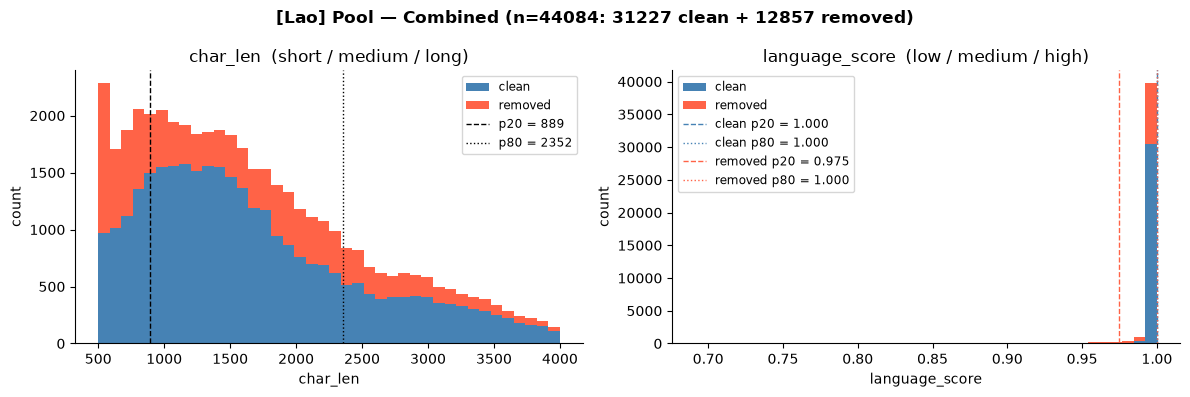

In [64]:
# ---- Combined pool distribution figure ----
import matplotlib.pyplot as plt

_POOL_COLORS = {"clean": "steelblue", "removed": "tomato"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("[%s] Pool — Combined (n=%d: %d clean + %d removed)"
             % (TARGET_LANGUAGE, len(pool), n_clean_pool, n_removed_pool), fontsize=12, fontweight="bold")

ax = axes[0]
ax.hist(
    [pool[pool["source"] == "clean"]["char_len"],
     pool[pool["source"] == "removed"]["char_len"]],
    bins=40, stacked=True,
    color=[_POOL_COLORS["clean"], _POOL_COLORS["removed"]],
    label=["clean", "removed"],
)
ax.axvline(LEN_LO, color="black", linestyle="--", linewidth=1,
           label="p%.0f = %d" % (LEN_Q[0]*100, LEN_LO))
ax.axvline(LEN_HI, color="black", linestyle=":",  linewidth=1,
           label="p%.0f = %d" % (LEN_Q[1]*100, LEN_HI))
ax.set_xlabel("char_len")
ax.set_ylabel("count")
ax.set_title("char_len  (short / medium / long)")
ax.legend(fontsize="small")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.hist(
    [pool[pool["source"] == "clean"]["language_score"],
     pool[pool["source"] == "removed"]["language_score"]],
    bins=40, stacked=True,
    color=[_POOL_COLORS["clean"], _POOL_COLORS["removed"]],
    label=["clean", "removed"],
)
for src, (lo, hi) in _lang_boundaries.items():
    _c = _POOL_COLORS[src]
    ax.axvline(lo, color=_c, linestyle="--", linewidth=1,
               label="%s p%.0f = %.3f" % (src, LANG_Q[0]*100, lo))
    ax.axvline(hi, color=_c, linestyle=":",  linewidth=1,
               label="%s p%.0f = %.3f" % (src, LANG_Q[1]*100, hi))
ax.set_xlabel("language_score")
ax.set_ylabel("count")
ax.set_title("language_score  (low / medium / high)")
ax.legend(fontsize="small")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pool_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Iterative scoring loop

Scores documents in batches of `BATCH_SIZE`. After each batch:
- Prints a dimension x score-value coverage table (bins below `FLOOR` marked with ▼).
- Tracks per-bin improvement; marks a bin **abandoned** after `GIVE_UP_AFTER` batches
  without progress (some bins are simply rare in Vietnamese web text).
- Stops when all open bins are met, the Gemini budget is exhausted, or the pool is empty.

The checkpoint (`gemini_scores_checkpoint.jsonl`) is append-only: re-running this cell
resumes from where it left off.


In [65]:
from collections import Counter

# ---- Resume from checkpoint ----
scored_by_id = {}    # id -> parsed score record (parse_status == "ok")
attempted_ids = set()

if SCORES_CKPT.exists():
    with open(SCORES_CKPT, encoding="utf-8") as fh:
        for line in fh:
            try:
                rec = json.loads(line)
                attempted_ids.add(rec["id"])
                if rec.get("parse_status") == "ok":
                    scored_by_id[rec["id"]] = rec
            except Exception:
                pass
    n_failed = len(attempted_ids) - len(scored_by_id)
    print("Resumed: %d successfully scored, %d failed." % (len(scored_by_id), n_failed))
    print("  Checkpoint:", SCORES_CKPT)
else:
    print("Starting fresh — no checkpoint found.")
    print("  Checkpoint will be written to:", SCORES_CKPT)


# ---- Gap helpers ----

def compute_gaps(scored, dead):
    """Return {(dim, score_val): shortfall} for bins below FLOOR, excluding dead bins."""
    gaps = {}
    for d in DIMENSIONS:
        counts = Counter(
            int(rec[d]) for rec in scored.values() if rec.get(d) is not None
        )
        for s in range(6):
            if (d, s) not in dead:
                shortfall = FLOOR - counts.get(s, 0)
                if shortfall > 0:
                    gaps[(d, s)] = shortfall
    return gaps


def print_gap_table(scored, gaps):
    DIM_W = 24
    header = "  " + "Dimension".ljust(DIM_W) + "".join(str(s).rjust(5) for s in range(6))
    print("  Score distribution (▼ = below FLOOR=%d):" % FLOOR)
    print(header)
    print("  " + "-" * len(header))
    for d in DIMENSIONS:
        counts = Counter(
            int(rec[d]) for rec in scored.values() if rec.get(d) is not None
        )
        row = "  " + d.ljust(DIM_W)
        for s in range(6):
            c = counts.get(s, 0)
            mark = "▼" if (d, s) in gaps else " "
            row += (mark + str(c)).rjust(5)
        print(row)
    total_gap = sum(gaps.values())
    print(
        "  Total gap: %d across %d open bins | Scored OK: %d docs"
        % (total_gap, len(gaps), len(scored))
    )


def print_batch_composition(batch_df):
    """Print a 3×3 (len × lang) count table for the docs about to be scored."""
    col_w = 10
    print("  Composition (len_bucket × lang_bucket):")
    print("  " + "%-8s" % "" + "".join(lg.center(col_w) for lg in LANG_LABELS) + "  total")
    print("  " + "-" * (8 + col_w * len(LANG_LABELS) + 7))
    for ln in LEN_LABELS:
        row = "  %-8s" % ln
        row_total = 0
        for lg in LANG_LABELS:
            cnt = int(((batch_df["len_bucket"] == ln) & (batch_df["lang_bucket"] == lg)).sum())
            row += str(cnt).center(col_w)
            row_total += cnt
        print(row + "  %d" % row_total)
    totals = [int((batch_df["lang_bucket"] == lg).sum()) for lg in LANG_LABELS]
    print("  " + "%-8s" % "total" + "".join(str(t).center(col_w) for t in totals) + "  %d" % len(batch_df))
    if "source" in batch_df.columns:
        n_clean   = int((batch_df["source"] == "clean").sum())
        n_removed = int((batch_df["source"] == "removed").sum())
        print("  source: clean=%d, removed=%d" % (n_clean, n_removed))


# ---- Initial state ----
dead_bins = set()
gaps = compute_gaps(scored_by_id, dead_bins)
print("\n" + "=" * 60)
print("INITIAL STATE")
print_gap_table(scored_by_id, gaps)

# ---- Main loop — iterate over pre-assigned batches in order ----
import time as _time
loop_start = _time.time()

batch_ids = sorted(pool["batch_id"].unique())
stall_count = 0
prev_total_gap = sum(gaps.values())
total_failed = len(attempted_ids) - len(scored_by_id)

for bid in batch_ids:
    if not gaps:
        break
    if len(attempted_ids) >= MAX_GEMINI_CALLS:
        print("Gemini call budget reached (%d)." % MAX_GEMINI_CALLS)
        break

    batch_df = pool[pool["batch_id"] == bid]
    unscored = batch_df[~batch_df["id"].isin(attempted_ids)]

    if unscored.empty:
        print("\nBatch %d: all docs already attempted — skipping." % bid)
        continue

    take = min(len(unscored), MAX_GEMINI_CALLS - len(attempted_ids))
    candidates = unscored.iloc[:take].to_dict("records")

    total_attempted = len(attempted_ids) + len(candidates)
    print("\n" + "=" * 60)
    print(
        "BATCH %d: scoring %d docs (total attempted: %d/%d)"
        % (bid, len(candidates), total_attempted, MAX_GEMINI_CALLS)
    )
    print_batch_composition(unscored.iloc[:take])

    results = score_batch(candidates, ckpt_path=SCORES_CKPT)

    batch_ok = 0
    batch_fail = 0
    for r in candidates:
        attempted_ids.add(r["id"])
    for s in results:
        doc_id = s["id"]
        all_ok = all(s.get(d) is not None for d in DIMENSIONS)
        if all_ok:
            scored_by_id[doc_id] = {
                "id": doc_id,
                "parse_status": "ok",
                "error": None,
                **{d: int(s.get(d)) for d in DIMENSIONS},
                "justification": s.get("justification", ""),
            }
            batch_ok += 1
        else:
            batch_fail += 1
    total_failed += batch_fail

    elapsed = _time.time() - loop_start
    print(
        "  Batch result: %d ok, %d failed (NaN/parse error) | Cumulative failed: %d | Elapsed: %dm %ds"
        % (batch_ok, batch_fail, total_failed, elapsed // 60, elapsed % 60)
    )

    gaps = compute_gaps(scored_by_id, dead_bins)
    print_gap_table(scored_by_id, gaps)

    current_total_gap = sum(gaps.values())
    if current_total_gap < prev_total_gap:
        stall_count = 0
    else:
        stall_count += 1
        print("  [STALL %d/%d] Total gap unchanged or grew (%d -> %d)."
              % (stall_count, GIVE_UP_AFTER, prev_total_gap, current_total_gap))

    prev_total_gap = current_total_gap

    if stall_count >= GIVE_UP_AFTER:
        new_dead = set(gaps.keys()) - dead_bins
        dead_bins.update(new_dead)
        print(
            "  [GIVE UP] Total gap did not decrease for %d batches. "
            "Abandoning %d open bins."
            % (GIVE_UP_AFTER, len(new_dead))
        )
        for b in sorted(str(x) for x in new_dead):
            print("    -", b)
        gaps = compute_gaps(scored_by_id, dead_bins)
        break

total_elapsed = _time.time() - loop_start
h = int(total_elapsed // 3600)
m = int((total_elapsed % 3600) // 60)
s = int(total_elapsed % 60)

print("\n" + "=" * 60)
print("SCORING COMPLETE")
print_gap_table(scored_by_id, compute_gaps(scored_by_id, set()))
print(
    "\nTotal attempted: %d | OK: %d | Failed: %d"
    % (len(attempted_ids), len(scored_by_id), total_failed)
)
print("Running time: %dh %dm %ds" % (h, m, s))
if dead_bins:
    print("Abandoned bins (%d):" % len(dead_bins), sorted(str(b) for b in dead_bins))
print("  Checkpoint:", SCORES_CKPT)

Starting fresh — no checkpoint found.
  Checkpoint will be written to: d:\CoRaL\data_revised\lao_Laoo\gemini_scores_checkpoint.jsonl

INITIAL STATE
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value          ▼0   ▼0   ▼0   ▼0   ▼0   ▼0
  reasoning                  ▼0   ▼0   ▼0   ▼0   ▼0   ▼0
  professionalism            ▼0   ▼0   ▼0   ▼0   ▼0   ▼0
  cleanliness                ▼0   ▼0   ▼0   ▼0   ▼0   ▼0
  cultural_nuances           ▼0   ▼0   ▼0   ▼0   ▼0   ▼0
  Total gap: 750 across 30 open bins | Scored OK: 0 docs

BATCH 0: scoring 309 docs (total attempted: 309/5000)
  Composition (len_bucket × lang_bucket):
             low      medium     high     total
  ---------------------------------------------
  short       17        38        7       62
  medium      33       112        39      184
  long        13        33        17      63
  total       63      

scoring: 100%|██████████| 309/309 [00:34<00:00,  9.08it/s]


  Batch result: 309 ok, 0 failed (NaN/parse error) | Cumulative failed: 0 | Elapsed: 0m 34s
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value          38   75  113   74   ▼9   ▼0
  reasoning                  69   84  125   31   ▼0   ▼0
  professionalism            ▼0   56  181   72   ▼0   ▼0
  cleanliness                ▼4   71   43   28   44  119
  cultural_nuances          ▼11  110   61   50   48   29
  Total gap: 201 across 9 open bins | Scored OK: 309 docs

BATCH 1: scoring 309 docs (total attempted: 618/5000)
  Composition (len_bucket × lang_bucket):
             low      medium     high     total
  ---------------------------------------------
  short       17        38        7       62
  medium      33       112        39      184
  long        13        33        17      63
  total       63       183        63      309
  source: clean=217, removed=92

scoring: 100%|██████████| 309/309 [00:33<00:00,  9.15it/s]


  Batch result: 309 ok, 0 failed (NaN/parse error) | Cumulative failed: 0 | Elapsed: 1m 7s
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value          78  145  218  161  ▼16   ▼0
  reasoning                 132  184  243   59   ▼0   ▼0
  professionalism            ▼0  127  352  139   ▼0   ▼0
  cleanliness               ▼10  140   76   55  112  225
  cultural_nuances           27  210  125  104   95   57
  Total gap: 174 across 8 open bins | Scored OK: 618 docs

BATCH 2: scoring 309 docs (total attempted: 927/5000)
  Composition (len_bucket × lang_bucket):
             low      medium     high     total
  ---------------------------------------------
  short       17        38        7       62
  medium      33       112        39      184
  long        13        33        17      63
  total       63       183        63      309
  source: clean=217, removed=92


...

  Batch result: 309 ok, 0 failed (NaN/parse error) | Cumulative failed: 1 | Elapsed: 5m 37s
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value         376  758 1038  816  101   ▼0
  reasoning                 595 1006 1164  322   ▼2   ▼0
  professionalism            ▼0  674 1735  669  ▼11   ▼0
  cleanliness                47  740  390  276  541 1095
  cultural_nuances          121 1042  619  543  486  278
  Total gap: 137 across 6 open bins | Scored OK: 3089 docs

BATCH 10: scoring 309 docs (total attempted: 3399/5000)
  Composition (len_bucket × lang_bucket):
             low      medium     high     total
  ---------------------------------------------
  short       17        38        7       62
  medium      33       112        39      184
  long        13        33        17      63
  total       63       183        63      309
  source: clean=217, removed

scoring: 100%|██████████| 309/309 [00:33<00:00,  9.20it/s]


  Batch result: 309 ok, 0 failed (NaN/parse error) | Cumulative failed: 1 | Elapsed: 6m 11s
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value         410  854 1119  905  110   ▼0
  reasoning                 661 1105 1280  350   ▼2   ▼0
  professionalism            ▼0  752 1905  730  ▼11   ▼0
  cleanliness                51  814  429  306  589 1209
  cultural_nuances          133 1142  683  591  543  306
  Total gap: 137 across 6 open bins | Scored OK: 3398 docs
  [STALL 1/2] Total gap unchanged or grew (137 -> 137).

BATCH 11: scoring 309 docs (total attempted: 3708/5000)
  Composition (len_bucket × lang_bucket):
             low      medium     high     total
  ---------------------------------------------
  short       17        38        7       62
  medium      33       112        39      184
  long        13        33        17      63
  total       63  

scoring: 100%|██████████| 309/309 [00:34<00:00,  9.06it/s]

  Batch result: 309 ok, 0 failed (NaN/parse error) | Cumulative failed: 1 | Elapsed: 6m 45s
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3    4    5
  --------------------------------------------------------
  educational_value         436  933 1218  996  124   ▼0
  reasoning                 717 1192 1412  384   ▼2   ▼0
  professionalism            ▼0  808 2083  805  ▼11   ▼0
  cleanliness                52  886  458  343  638 1330
  cultural_nuances          144 1231  755  646  602  329
  Total gap: 137 across 6 open bins | Scored OK: 3707 docs
  [STALL 2/2] Total gap unchanged or grew (137 -> 137).
  [GIVE UP] Total gap did not decrease for 2 batches. Abandoning 6 open bins.
    - ('educational_value', 5)
    - ('professionalism', 0)
    - ('professionalism', 4)
    - ('professionalism', 5)
    - ('reasoning', 4)
    - ('reasoning', 5)

SCORING COMPLETE
  Score distribution (▼ = below FLOOR=25):
  Dimension                   0    1    2    3

Distributions of `char_len`, `language_score`, and all 5 dimension scores
across **all successfully scored documents** before the final selection filter.


Scored docs: 3707 total (2604 clean, 1103 removed)


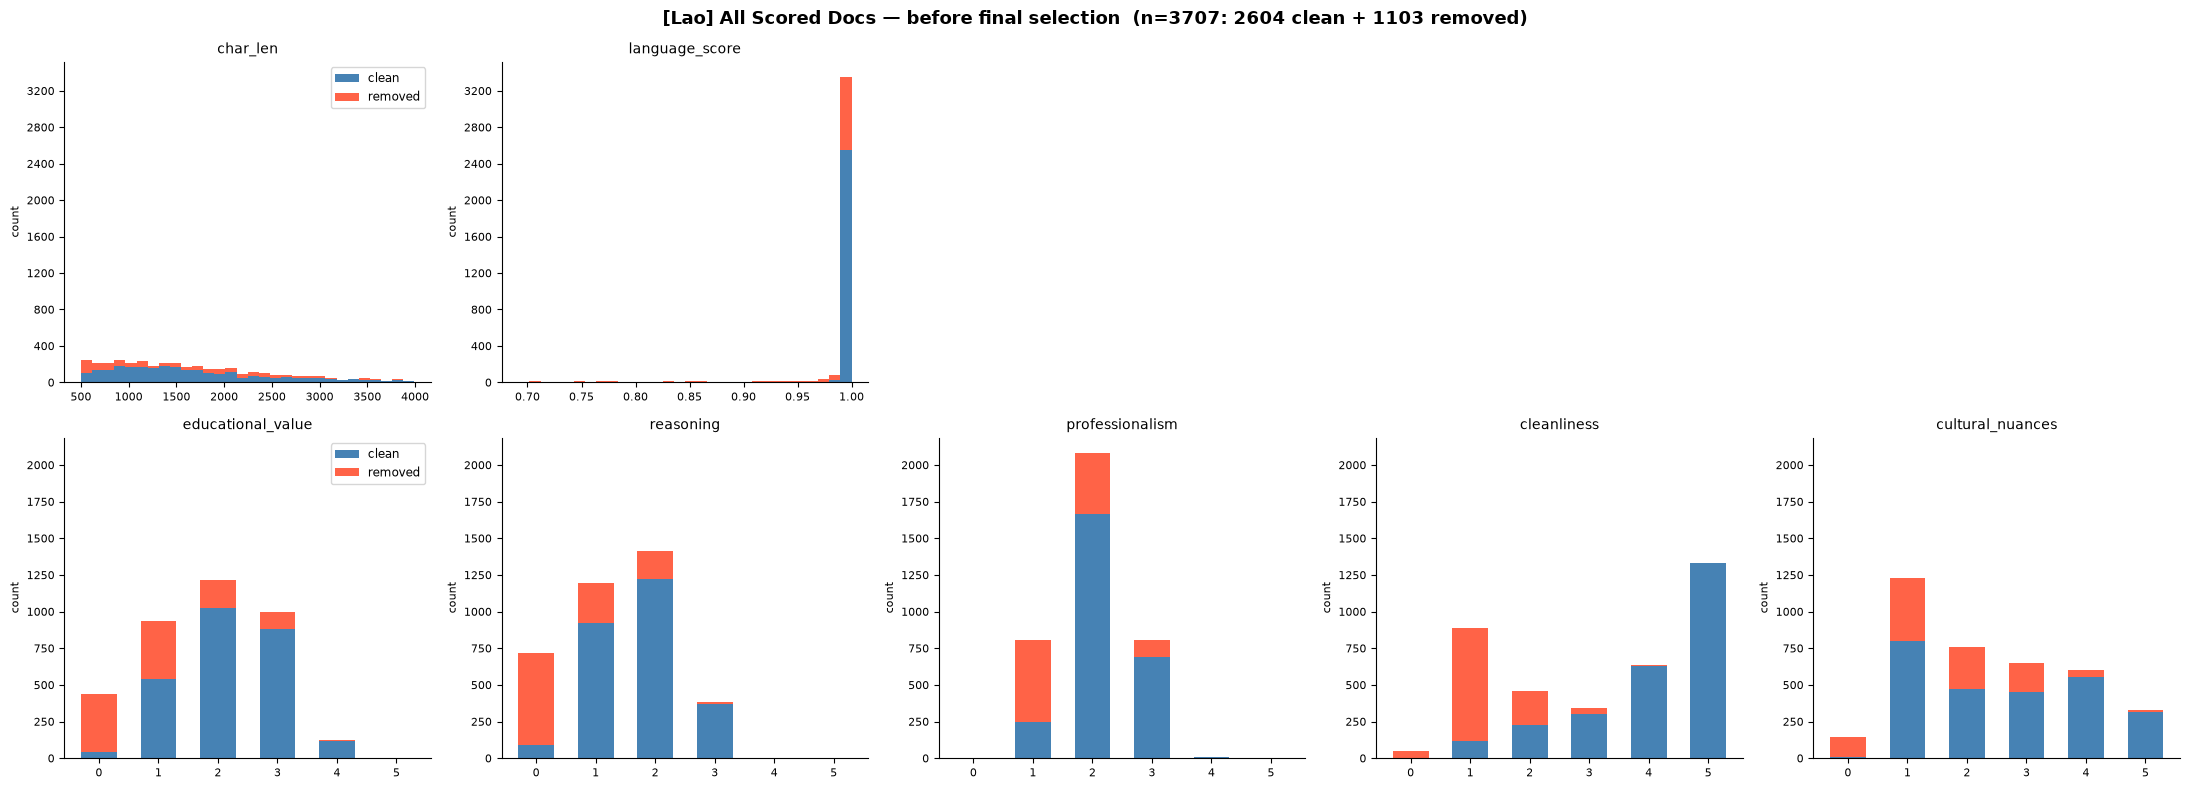

In [66]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from collections import Counter as _Counter

# Build a DataFrame of all successfully scored docs joined with pool metadata
_pool_by_id = pool.set_index("id")
_scored_rows = []
for _id, _rec in scored_by_id.items():
    if not all(_rec.get(d) is not None for d in DIMENSIONS):
        continue
    if _id not in _pool_by_id.index:
        continue
    _row = _pool_by_id.loc[_id].to_dict()
    _scored_rows.append({**_row, "id": _id, **{d: int(_rec[d]) for d in DIMENSIONS}})

scored_df = pd.DataFrame(_scored_rows)
_n_total   = len(scored_df)
_n_clean   = int((scored_df["source"] == "clean").sum())
_n_removed = int((scored_df["source"] == "removed").sum())
print("Scored docs: %d total (%d clean, %d removed)" % (_n_total, _n_clean, _n_removed))

_COLORS = {"clean": "steelblue", "removed": "tomato"}

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle("[%s] All Scored Docs — before final selection  (n=%d: %d clean + %d removed)"
             % (TARGET_LANGUAGE, _n_total, _n_clean, _n_removed), fontsize=13, fontweight="bold")

def _fmt(ax, title):
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# ---- Row 0: char_len and language_score histograms ----
ax = axes[0, 0]
ax.hist(
    [scored_df[scored_df["source"] == "clean"]["char_len"],
     scored_df[scored_df["source"] == "removed"]["char_len"]],
    bins=30, stacked=True,
    color=[_COLORS["clean"], _COLORS["removed"]], label=["clean", "removed"],
)
ax.legend(fontsize="small")
_fmt(ax, "char_len")

ax = axes[0, 1]
ax.hist(
    [scored_df[scored_df["source"] == "clean"]["language_score"],
     scored_df[scored_df["source"] == "removed"]["language_score"]],
    bins=30, stacked=True,
    color=[_COLORS["clean"], _COLORS["removed"]], label=["clean", "removed"],
)
_fmt(ax, "language_score")

for _col in range(2, 5):
    axes[0, _col].axis("off")

# ---- Row 1: 5 dimension score distributions ----
for _col, d in enumerate(DIMENSIONS):
    ax = axes[1, _col]
    _c = (scored_df[scored_df["source"] == "clean"][d]
          .value_counts().sort_index().reindex(range(6), fill_value=0))
    _r = (scored_df[scored_df["source"] == "removed"][d]
          .value_counts().sort_index().reindex(range(6), fill_value=0))
    xs = list(range(6))
    ax.bar(xs, _c, color=_COLORS["clean"],   label="clean",   width=0.6)
    ax.bar(xs, _r, color=_COLORS["removed"], label="removed", width=0.6, bottom=_c)
    ax.set_xticks(xs)
    if _col == 0:
        ax.legend(fontsize="small")
    _fmt(ax, d)

# Unify y-axes within each row
for _row_axes in [[axes[0, 0], axes[0, 1]], list(axes[1, :])]:
    _top = max(ax.get_ylim()[1] for ax in _row_axes)
    for ax in _row_axes:
        ax.set_ylim(0, _top)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "scored_docs_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Final selection

From all successfully scored documents, select exactly `TARGET_TOTAL` using a greedy algorithm:
- **Primary:** maximise coverage of underfilled (dimension, score-value) bins.
- **Secondary:** prefer underrepresented length buckets and language-score tiers.


In [67]:
from tqdm.auto import tqdm as _tqdm_sel

# Build list of usable scored docs joined with pool text + metadata
pool_by_id = pool.set_index("id")
scored_docs = []
for doc_id, rec in scored_by_id.items():
    if not all(rec.get(d) is not None for d in DIMENSIONS):
        continue
    if doc_id not in pool_by_id.index:
        continue
    row = pool_by_id.loc[doc_id].to_dict()
    scored_docs.append({
        **row,
        "id": doc_id,
        **{d: int(rec[d]) for d in DIMENSIONS},
        "justification": rec.get("justification", ""),
    })

n_clean_avail   = sum(1 for d in scored_docs if d.get("source") == "clean")
n_removed_avail = sum(1 for d in scored_docs if d.get("source") == "removed")
print("Usable scored docs available for selection: %d" % len(scored_docs))
print("  source breakdown: %d clean, %d removed" % (n_clean_avail, n_removed_avail))
print("  targets: %d clean, %d removed (total %d)" % (TARGET_CLEAN, TARGET_REMOVED, TARGET_TOTAL))

if not scored_docs:
    raise RuntimeError("No successfully scored docs found — re-run the scoring loop.")

if len(scored_docs) <= TARGET_TOTAL:
    print("WARNING: only %d docs available — taking all." % len(scored_docs))
    selected = scored_docs
else:
    bin_counts = {(d, s): 0 for d in DIMENSIONS for s in range(6)}
    len_counts: Counter = Counter()
    lang_counts: Counter = Counter()
    clean_count   = 0
    removed_count = 0

    def contribution(doc, n_selected):
        """Greedy diversity score. Returns -1 if this doc's source quota is full."""
        src = doc.get("source", "clean")
        if src == "clean"   and clean_count   >= TARGET_CLEAN:   return -1
        if src == "removed" and removed_count >= TARGET_REMOVED: return -1
        primary = sum(max(0, FLOOR - bin_counts[(d, int(doc[d]))]) for d in DIMENSIONS)
        lb = doc["len_bucket"]
        len_frac     = LEN_TARGET_FRAC.get(lb, 1/3)
        expected_len = max(1, int(n_selected * len_frac))
        len_deficit  = max(0, expected_len - len_counts.get(lb, 0))
        lg = doc.get("lang_bucket", "high")
        lang_frac     = LANG_TARGET_FRAC.get(lg, 0.5)
        expected_lang = max(1, int(n_selected * lang_frac))
        lang_deficit  = max(0, expected_lang - lang_counts.get(lg, 0))
        return primary + 0.1 * len_deficit + 0.05 * lang_deficit

    remaining = scored_docs.copy()
    _rng = random.Random(SEED)
    _rng.shuffle(remaining)
    selected = []

    pbar = _tqdm_sel(total=TARGET_TOTAL, desc="selecting")
    while len(selected) < TARGET_TOTAL and remaining:
        scores = [contribution(remaining[i], len(selected)) for i in range(len(remaining))]
        best_score = max(scores)
        if best_score < 0:
            break  # all remaining docs have exhausted their source quotas
        best_i = scores.index(best_score)
        doc = remaining.pop(best_i)
        selected.append(doc)
        for d in DIMENSIONS:
            bin_counts[(d, int(doc[d]))] += 1
        len_counts[doc["len_bucket"]] += 1
        lang_counts[doc.get("lang_bucket", "normal")] += 1
        if doc.get("source") == "clean":
            clean_count += 1
        else:
            removed_count += 1
        pbar.update(1)
    pbar.close()

print("\nSelected: %d documents (%d clean, %d removed)" % (len(selected), clean_count, removed_count))

# Print final distributions
sel_df = pd.DataFrame(selected)
print("\nDimension distributions (score : count):")
for d in DIMENSIONS:
    vc = sel_df[d].value_counts().sort_index()
    print("  %s: %s" % (d, dict(vc)))
print("\nLength bucket:", dict(sel_df["len_bucket"].value_counts().sort_index()))
print("Language bucket:", dict(sel_df["lang_bucket"].value_counts().sort_index()))
print("Source:", dict(sel_df["source"].value_counts()))

Usable scored docs available for selection: 3707
  source breakdown: 2604 clean, 1103 removed
  targets: 658 clean, 282 removed (total 940)


selecting: 100%|██████████| 940/940 [00:09<00:00, 101.62it/s]



Selected: 940 documents (658 clean, 282 removed)

Dimension distributions (score : count):
  educational_value: {0: np.int64(95), 1: np.int64(178), 2: np.int64(312), 3: np.int64(319), 4: np.int64(36)}
  reasoning: {0: np.int64(126), 1: np.int64(264), 2: np.int64(403), 3: np.int64(145), 4: np.int64(2)}
  professionalism: {1: np.int64(168), 2: np.int64(534), 3: np.int64(227), 4: np.int64(11)}
  cleanliness: {0: np.int64(25), 1: np.int64(207), 2: np.int64(108), 3: np.int64(85), 4: np.int64(173), 5: np.int64(342)}
  cultural_nuances: {0: np.int64(31), 1: np.int64(260), 2: np.int64(182), 3: np.int64(198), 4: np.int64(177), 5: np.int64(92)}

Length bucket: {'long': np.int64(290), 'medium': np.int64(361), 'short': np.int64(289)}
Language bucket: {'high': np.int64(609), 'low': np.int64(111), 'medium': np.int64(220)}
Source: {'clean': np.int64(658), 'removed': np.int64(282)}


## 10. Export

Writes four files:
- **`selected_final.csv`** — full data (text + metadata + Gemini scores).
- **`annotator_batch.csv`** — `id` and `text` only. **No AI scores** (Rule 1).
- **`selection_report.csv`** — per-(dim, score-value) counts with `clean_count` / `removed_count` breakdown + metadata bucket counts.


In [68]:
final = pd.DataFrame(selected).drop_duplicates("id").reset_index(drop=True)
print("FINAL SET: %d documents\n" % len(final))

_clean   = final["source"] == "clean"
_removed = final["source"] == "removed"

# selected_final.csv
final.to_csv(SELECTED_CSV, index=False, encoding="utf-8-sig")
print("Saved:", SELECTED_CSV)

# annotator_batch.csv — id + text only, NO scores, NO source (Rule 1)
ann = final[["id", "text"]].sample(frac=1.0, random_state=SEED).reset_index(drop=True)
ann.to_csv(ANNOTATOR_CSV, index=False, encoding="utf-8-sig")
print("Saved:", ANNOTATOR_CSV)

# selection_report.csv — count + per-source breakdown for every row
def _counts(mask):
    return {
        "count":         int(mask.sum()),
        "clean_count":   int((mask & _clean).sum()),
        "removed_count": int((mask & _removed).sum()),
    }

report_rows = []
for d in DIMENSIONS:
    for s in range(6):
        report_rows.append({
            "type": "dimension", "name": d, "value": str(s),
            **_counts(final[d] == s),
        })
for lb in ["short", "medium", "long"]:
    report_rows.append({
        "type": "len_bucket", "name": "len_bucket", "value": lb,
        **_counts(final["len_bucket"] == lb),
    })
for lt in ["low", "normal"]:
    report_rows.append({
        "type": "lang_bucket", "name": "lang_bucket", "value": lt,
        **_counts(final["lang_bucket"] == lt),
    })
for src in ["clean", "removed"]:
    report_rows.append({
        "type": "source", "name": "source", "value": src,
        **_counts(final["source"] == src),
    })
pd.DataFrame(report_rows).to_csv(SELECTION_REPORT, index=False)
print("Saved:", SELECTION_REPORT)

print("\nAll output files:")
print("  ", SELECTED_CSV)
print("  ", ANNOTATOR_CSV)
print("  ", SELECTION_REPORT)
print("  ", SCORES_CKPT)


FINAL SET: 940 documents

Saved: d:\CoRaL\data_revised\lao_Laoo\selected_final.csv
Saved: d:\CoRaL\data_revised\lao_Laoo\annotator_batch.csv
Saved: d:\CoRaL\data_revised\lao_Laoo\selection_report.csv

All output files:
   d:\CoRaL\data_revised\lao_Laoo\selected_final.csv
   d:\CoRaL\data_revised\lao_Laoo\annotator_batch.csv
   d:\CoRaL\data_revised\lao_Laoo\selection_report.csv
   d:\CoRaL\data_revised\lao_Laoo\gemini_scores_checkpoint.jsonl


## 11. Visual diagnostics

Length distribution, language-score tier split, and all five dimension histograms.


In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

final = pd.read_csv(SELECTED_CSV, encoding="utf-8-sig")

_COLORS = {"clean": "steelblue", "removed": "tomato"}

def _bar(ax, categories, vals, color):
    xs = list(range(len(categories)))
    ax.bar(xs, vals, color=color, width=0.6)
    ax.set_xticks(xs)
    ax.set_xticklabels(list(categories), rotation=0)

def _stacked_bar(ax, categories, clean_vals, removed_vals):
    xs = list(range(len(categories)))
    ax.bar(xs, clean_vals,   color=_COLORS["clean"],   label="clean",   width=0.6)
    ax.bar(xs, removed_vals, color=_COLORS["removed"], label="removed", width=0.6,
           bottom=clean_vals)
    ax.set_xticks(xs)
    ax.set_xticklabels(list(categories), rotation=0)

def _fmt(ax, title):
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

_META_COLS = [
    ("len_bucket",  ["short", "medium", "long"], "char_len"),
    ("lang_bucket", ["low", "medium", "high"],    "language_score"),
]

for (label, subset) in [
    ("Clean (n=%d)"    % int((final["source"] == "clean").sum()),   final[final["source"] == "clean"]),
    ("Removed (n=%d)"  % int((final["source"] == "removed").sum()), final[final["source"] == "removed"]),
    ("Combined (n=%d)" % len(final),                                final),
]:
    if subset.empty:
        print("No docs for:", label)
        continue
    is_combined = label.startswith("Combined")
    src_color = _COLORS["clean"] if label.startswith("Clean") else _COLORS["removed"]

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle("[%s] %s" % (TARGET_LANGUAGE, label), fontsize=14, fontweight="bold")

    # ---- Row 0: metadata ----
    for ax_idx, (col, cats, val_col) in enumerate(_META_COLS):
        ax = axes[0, ax_idx]
        if is_combined:
            clean_vals   = subset[subset["source"] == "clean"][val_col]
            removed_vals = subset[subset["source"] == "removed"][val_col]
            ax.hist(
                [clean_vals, removed_vals],
                bins=20, stacked=True,
                color=[_COLORS["clean"], _COLORS["removed"]],
                label=["clean", "removed"],
            )
            ax.set_xlabel(val_col, fontsize=8)
            if ax_idx == 0:
                ax.legend(fontsize="small")
            _fmt(ax, val_col)
        else:
            vals = subset[col].value_counts().reindex(cats, fill_value=0)
            _bar(ax, cats, vals, src_color)
            _fmt(ax, col)

    for col in range(2, 5):
        axes[0, col].axis("off")

    # ---- Row 1: dimension bar charts ----
    for col_idx, d in enumerate(DIMENSIONS):
        ax = axes[1, col_idx]
        if is_combined:
            c = (subset[subset["source"] == "clean"][d]
                 .value_counts().sort_index().reindex(range(6), fill_value=0))
            r = (subset[subset["source"] == "removed"][d]
                 .value_counts().sort_index().reindex(range(6), fill_value=0))
            _stacked_bar(ax, range(6), c, r)
        else:
            vals = subset[d].value_counts().sort_index().reindex(range(6), fill_value=0)
            _bar(ax, range(6), vals, src_color)
        _fmt(ax, d)

    # ---- Unified y-axis within each row ----
    for row_axes in [
        [axes[0, 0], axes[0, 1]],
        list(axes[1, :]),
    ]:
        top = max(ax.get_ylim()[1] for ax in row_axes)
        for ax in row_axes:
            ax.set_ylim(0, top)

    plt.tight_layout()
    _fname = label.split()[0].lower() + "_selection.png"
    plt.savefig(FIGURES_DIR / _fname, dpi=150, bbox_inches="tight")
    plt.show()

NameError: name 'pd' is not defined

## 12. Annotator batch files

Splits the final selected set into four annotation batches — **pilot** (40), **batch1**,
**batch2**, **batch3** (300 each, sizes must sum to `TARGET_TOTAL`) — using iterative
stratified sampling so every batch keeps roughly the same per-(dimension, score-value)
ratio as the full selected set (across all five quality dimensions).

Each file is a blank annotation template: `id`, `text`, the five dimension columns, and
`justification` — left empty for the human annotator to fill in (no AI scores, same
Rule 1 as `annotator_batch.csv`). Saved as CSVs under `annotator_batches/`.

Also appends a `<split>_count` column (real counts, not %) to `selection_report.csv` for
every existing row, so the per-split dimension/bucket breakdown is on record alongside
`count` / `clean_count` / `removed_count`.


In [4]:
from collections import Counter

# ---- Split sizes (must sum to len(final) == TARGET_TOTAL) ----
SPLIT_SIZES = {"pilot": 40, "batch1": 300, "batch2": 300, "batch3": 300}
assert sum(SPLIT_SIZES.values()) == len(final), (
    "Split sizes (%d) must match final set size (%d)" % (sum(SPLIT_SIZES.values()), len(final))
)

ANNOTATOR_BATCHES_DIR = WORK / "annotator_batches"
ANNOTATOR_BATCHES_DIR.mkdir(parents=True, exist_ok=True)

def _iterative_stratified_split(df, label_cols, split_sizes, seed=SEED):
    """Assign each row to a split so every split keeps roughly the same
    per-(column, value) ratio as the full set (iterative stratification,
    Sechidis et al. 2011 — process the rarest label first, and for each of
    its docs give it to whichever split still needs that label most)."""
    rng = np.random.RandomState(seed)
    split_names = list(split_sizes.keys())
    remaining_capacity = dict(split_sizes)

    doc_labels = {idx: [(c, row[c]) for c in label_cols] for idx, row in df.iterrows()}
    label_totals = Counter(lab for labs in doc_labels.values() for lab in labs)
    n = len(df)

    desired = {
        s: {lab: total * split_sizes[s] / n for lab, total in label_totals.items()}
        for s in split_names
    }

    assigned = {}
    remaining = set(df.index)
    while remaining:
        remaining_label_count = Counter()
        for idx in remaining:
            remaining_label_count.update(doc_labels[idx])
        lab = min(remaining_label_count, key=lambda l: remaining_label_count[l])
        candidates = [idx for idx in remaining if lab in doc_labels[idx]]
        rng.shuffle(candidates)
        for idx in candidates:
            eligible = [s for s in split_names if remaining_capacity[s] > 0]
            best = max(eligible, key=lambda s: (desired[s][lab], remaining_capacity[s]))
            assigned[idx] = best
            remaining_capacity[best] -= 1
            for l in doc_labels[idx]:
                desired[best][l] -= 1
            remaining.discard(idx)
    return pd.Series(assigned).reindex(df.index)

final["split"] = _iterative_stratified_split(final, DIMENSIONS, SPLIT_SIZES)

# ---- Sanity check: per-split, per-dimension bucket counts vs. full set ----
print("Split sizes:", final["split"].value_counts().reindex(SPLIT_SIZES.keys()).to_dict())
for d in DIMENSIONS:
    header = "%-20s  %8s " % (d, "full") + "".join("%9s" % s for s in SPLIT_SIZES.keys())
    print("\n" + header)
    for v in range(6):
        full_count = int((final[d] == v).sum())
        row = "  value=%d           %8d " % (v, full_count)
        for s in SPLIT_SIZES.keys():
            sub = final[final["split"] == s]
            cnt = int((sub[d] == v).sum())
            row += "%9d " % cnt
        print(row)

# ---- Persist per-split counts (real numbers, not %) into selection_report.csv ----
report = pd.read_csv(SELECTION_REPORT)

def _split_mask(row):
    if row["type"] == "dimension":
        return final[row["name"]] == int(row["value"])
    return final[row["name"]] == row["value"]

for s in SPLIT_SIZES:
    report["%s_count" % s] = [
        int((_split_mask(row) & (final["split"] == s)).sum())
        for _, row in report.iterrows()
    ]

report.to_csv(SELECTION_REPORT, index=False)
print("\nUpdated:", SELECTION_REPORT, "with columns:",
      ", ".join("%s_count" % s for s in SPLIT_SIZES))

# ---- Save blank annotation templates ----
TEMPLATE_COLS = ["id", "text"] + DIMENSIONS + ["justification"]

for split_name in SPLIT_SIZES:
    sub = final[final["split"] == split_name][["id", "text"]].copy()
    sub = sub.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    for col in DIMENSIONS + ["justification"]:
        sub[col] = ""
    sub = sub[TEMPLATE_COLS]
    out_path = ANNOTATOR_BATCHES_DIR / ("%s.csv" % split_name)
    sub.to_csv(out_path, index=False, encoding="utf-8-sig")
    print("Saved: %s (%d docs)" % (out_path, len(sub)))


NameError: name 'final' is not defined